In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from keras.layers import (
    Input,
    Dense,
    Flatten,
    Conv1D,
    MaxPooling1D
)
import tensorflow as tf

In [45]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [46]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [47]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']


# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

In [48]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(pd.Series(y_train).value_counts())

Diabetes_012
0.0    149523
2.0     24847
1.0      3206
Name: count, dtype: int64


In [49]:
# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [50]:
# Step 1: CNN Input
cnn_input = Input(shape=(X_train.shape[1], 1))

# CNN Layers
x = Conv1D(filters=32, kernel_size=2, activation='relu', padding='same')(cnn_input)

# Flatten
x = Flatten()(x)

# Output Layer
output_layer = Dense(3, activation='softmax')(x)

# Build Model
model = Model(inputs=cnn_input, outputs=output_layer)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Early stopping (monitor accuracy instead of loss)
early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True
)

# Start timing
start_time = tf.timestamp()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# End timing
end_time = tf.timestamp()

# Convert to float
total_time = float(end_time - start_time)
average_time_per_epoch = total_time / len(history.history['loss'])

# Print results
print(f'Total Training Time: {total_time:.2f} seconds')
print(f'Average Time per Epoch: {average_time_per_epoch:.2f} seconds')

Epoch 1/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8467 - loss: 0.4013
Epoch 2/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8477 - loss: 0.3975
Epoch 3/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8478 - loss: 0.3969
Epoch 4/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8482 - loss: 0.3966
Epoch 5/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8482 - loss: 0.3963
Epoch 6/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8482 - loss: 0.3962
Epoch 7/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8482 - loss: 0.3960
Epoch 8/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8483 - loss: 0.3960
Epoch 9/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8484 - loss: 0.3959
Epoch 10/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8484 - loss: 0.3958
Epoch 11/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8484 - loss: 0.3958
Epoch 12/20
5550/55

In [52]:
# ==============================
# 8. Evaluate Model
# ==============================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8497450947761536


In [53]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [54]:
# ==============================
# 8. Prediction
# ==============================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [55]:
# ==============================
# 9. Metrics
# ==============================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Weighted Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Confusion Matrix:
[[62855     0  1325]
 [ 1296     0   129]
 [ 8685     0  1814]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     64180
         1.0       0.00      0.00      0.00      1425
         2.0       0.56      0.17      0.26     10499

    accuracy                           0.85     76104
   macro avg       0.47      0.38      0.39     76104
weighted avg       0.80      0.85      0.81     76104


Weighted Precision: 0.8043
Weighted Recall: 0.8497
Weighted F1-Score: 0.8101


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

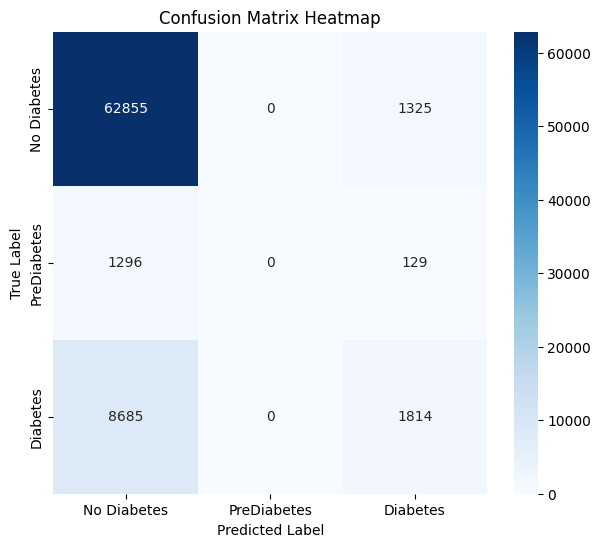

In [56]:
# ==============================
# 10. Confusion Matrix Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()